In [2]:
import glob
import math
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as io
import astropy.units as u
from astropy.coordinates import SkyCoord
from functools import reduce
from astropy import time

from sunpy.map import Map
from sunpy.net import Fido, attrs as a

from demregpy import dn2dem
from demregpy.tresp import aia_tresp

In [4]:
time_test = time.Time('2022-02-28T22:30:16', scale='utc')
wavenum = ['94', '131', '171', '193', '211', '335']

fdir = '/disk/plasma/xw2/sunpy/data/'
minute_str = time_test.iso[:16].replace(':', '').replace(' ', 'T')
target_dt = datetime.strptime(time_test.iso[:19], '%Y-%m-%d %H:%M:%S')

local_files = {}
missing_wl = []

for wl in wavenum:
    pattern = os.path.join(fdir, f"aia.lev1_euv_12s.{minute_str}*.{wl}.image_lev1.fits")
    matches = sorted(glob.glob(pattern))
    if matches:
        if len(matches) == 1:
            local_files[wl] = matches[0]
        else:
            def _parse_time(f):
                ts = os.path.basename(f).split('.')[2]
                return datetime.strptime(ts, '%Y-%m-%dT%H%M%SZ')
            matches.sort(key=lambda f: abs((_parse_time(f) - target_dt).total_seconds()))
            local_files[wl] = matches[0]
    else:
        missing_wl.append(wl)

if missing_wl:
    print(f"Missing wavelengths locally: {missing_wl}, will download from JSOC...")
    primekeys = [a.jsoc.PrimeKey('WAVELNTH', wl) for wl in missing_wl]
    q = Fido.search(
        a.Time(time_test, time_test + time.TimeDelta(1, format='sec')),
        a.jsoc.Series('aia.lev1_euv_12s'),
        reduce(lambda x, y: x | y, primekeys),
        a.jsoc.Segment('image'),
        a.jsoc.Notify('xiangyu.wu.23@ucl.ac.uk'),
    )
    fetched = Fido.fetch(q, path=fdir + '{file}')
    for f in fetched:
        for wl in missing_wl:
            if f'.{wl}.image_lev1' in str(f):
                local_files[wl] = str(f)
                break
else:
    print(f"All {len(local_files)} AIA files found locally, skipping JSOC export!")

assert len(local_files) == len(wavenum), f"Missing: {set(wavenum) - set(local_files.keys())}"
print("Local files:")
for wl in wavenum:
    print(f"  {wl}A: {os.path.basename(local_files[wl])}")

aia_map = Map(local_files['94'])

All 6 AIA files found locally, skipping JSOC export!
Local files:
  94A: aia.lev1_euv_12s.2022-02-28T223013Z.94.image_lev1.fits
  131A: aia.lev1_euv_12s.2022-02-28T223020Z.131.image_lev1.fits
  171A: aia.lev1_euv_12s.2022-02-28T223022Z.171.image_lev1.fits
  193A: aia.lev1_euv_12s.2022-02-28T223018Z.193.image_lev1.fits
  211A: aia.lev1_euv_12s.2022-02-28T223011Z.211.image_lev1.fits
  335A: aia.lev1_euv_12s.2022-02-28T223014Z.335.image_lev1.fits


In [18]:
print('unit of l1 aia image:', aia_map.unit)
aia_map.data

unit of l1 aia image: DN


array([[-1.  ,  1.  ,  1.  , ..., -0.75, -0.5 , -0.5 ],
       [-0.75, -0.75,  0.  , ...,  0.75,  0.5 ,  0.75],
       [-1.  , -0.75,  2.25, ..., -0.5 ,  1.25,  0.75],
       ...,
       [ 1.25,  0.5 ,  0.  , ...,  2.25, -1.75,  0.5 ],
       [-1.  ,  1.  ,  1.25, ...,  0.  ,  1.  ,  0.25],
       [-0.5 ,  0.  ,  1.25, ..., -1.25, -0.75,  0.25]],
      shape=(4096, 4096), dtype=float32)

In [14]:
prep_dir = '/disk/plasma/xw2/sunpy/data/aia_prep/'

maps = {}
for wl in wavenum:
    pattern = os.path.join(prep_dir, f'aia_prep_{wl}A_*.fits')
    matches = sorted(glob.glob(pattern))
    assert matches, f"No prepared map found for {wl} A in {prep_dir}"
    maps[wl] = Map(matches[-1])

maps_sorted = [maps[wl] for wl in wavenum]

print("Loaded prepared maps:")
for wl in wavenum:
    m = maps[wl]
    print(f"  {wl:>3} A: {m.data.shape}  date={m.date}  mean={np.mean(m.data):.2f} DN/s")

Loaded prepared maps:
   94 A: (4096, 4096)  date=2022-02-28T22:30:11.115  mean=0.82 DN/s
  131 A: (4096, 4096)  date=2022-02-28T22:30:18.622  mean=4.28 DN/s
  171 A: (4094, 4094)  date=2022-02-28T22:30:21.350  mean=111.36 DN/s
  193 A: (4096, 4096)  date=2022-02-28T22:30:16.847  mean=174.31 DN/s
  211 A: (4096, 4096)  date=2022-02-28T22:30:09.626  mean=72.16 DN/s
  335 A: (4096, 4096)  date=2022-02-28T22:30:12.626  mean=3.10 DN/s


In [24]:
aa = maps['94'].data*maps['94'].exposure_time.value
aa.mean()

np.float64(2.3686623316672586)

new prepared aia, in DN

In [26]:
prep_dir = '/disk/plasma/xw2/sunpy/data/aia_prep/'

maps = {}
for wl in wavenum:
    pattern = os.path.join(prep_dir, f'aia_prep_{wl}A_*.fits')
    matches = sorted(glob.glob(pattern))
    assert matches, f"No prepared map found for {wl} A in {prep_dir}"
    maps[wl] = Map(matches[-1])

maps_sorted = [maps[wl] for wl in wavenum]

print("Loaded prepared maps:")
for wl in wavenum:
    m = maps[wl]
    print(f"  {wl:>3} A: {m.data.shape}  date={m.date}  mean={np.mean(m.data):.2f} DN/s")

Loaded prepared maps:
   94 A: (4096, 4096)  date=2022-02-28T22:30:11.115  mean=2.37 DN/s
  131 A: (4096, 4096)  date=2022-02-28T22:30:18.622  mean=12.42 DN/s
  171 A: (4094, 4094)  date=2022-02-28T22:30:21.350  mean=222.68 DN/s
  193 A: (4096, 4096)  date=2022-02-28T22:30:16.847  mean=348.56 DN/s
  211 A: (4096, 4096)  date=2022-02-28T22:30:09.626  mean=209.34 DN/s
  335 A: (4096, 4096)  date=2022-02-28T22:30:12.626  mean=9.00 DN/s


In [27]:
bb = maps['94'].data*maps['94'].exposure_time.value
bb.mean()

np.float64(6.871086751570334)

## Test uncertainty
wilson's method

In [51]:
# Work out the uncertainty 
# And the associated uncertainty
# If using AIA see Boerner et al. 2012 or see the sswidl aia_bp_estimate_error.pro
# Values specifically for AIA
gains=np.array([18.3])#np.array([18.3,17.6,17.7,18.3,18.3,17.6])
dn2ph=gains*np.array([94])/3397. #gains*np.array([94,131,171,193,211,335])/3397.
rdnse=np.array([1.14])#np.array([1.14,1.18,1.15,1.20,1.20,1.18])
# Just the sqrt of the total photons detected, so going DN/px -> ph -> DN/px (deg corrected DN)
num_pix=1
shotnoise=(dn2ph*maps['94'].data*num_pix)**0.5/dn2ph/num_pix
# Combine errors and put into DN/px/s
edn_in=(rdnse**2+shotnoise**2)**0.5#/maps['94'].exposure_time.value
print('edn_in: ',edn_in)

edn_in:  [[1.14       1.14       1.14       ... 1.14       1.14       1.14      ]
 [1.14       1.14       1.14       ... 1.14       1.14       1.14      ]
 [1.14       1.14       1.14       ... 1.14       1.14       1.14      ]
 ...
 [1.83908245 1.55125186 1.40144608 ... 1.14       1.14       1.14      ]
 [1.72269053 1.35819195 1.63871103 ... 1.14       1.14       1.14      ]
 [2.55918778 2.20182342 1.14       ... 1.14       1.14       1.14      ]]


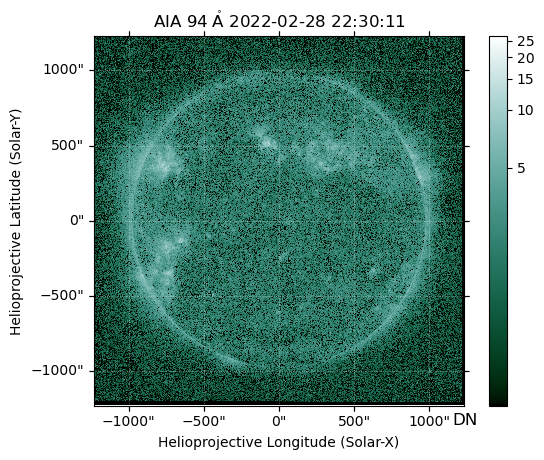

In [53]:
# errors_94
map_94_errors_manual = Map(edn_in, maps['94'].meta)
map_94_errors_manual.peek()

aiapy error estimate

In [ ]:
from aiapy.calibrate import estimate_error
from aiapy.calibrate.utils import get_error_table
error_table = get_error_table("SSW")
errors_94 = estimate_error(maps['94'].quantity / u.pix, maps['94'].wavelength, error_table=error_table)

In [50]:
errors_94.value/maps['94'].exposure_time.value

array([[0.41011636, 0.41011636, 0.41011636, ..., 0.41011636, 0.41011636,
        0.41011636],
       [0.41011636, 0.41011636, 0.41011636, ..., 0.41011636, 0.41011636,
        0.41011636],
       [0.41011636, 0.41011636, 0.41011636, ..., 0.41011636, 0.41011636,
        0.41011636],
       ...,
       [0.64476288, 0.54748384, 0.49715859, ..., 0.41011636, 0.41011636,
        0.41011636],
       [0.60534928, 0.48267984, 0.57697245, ..., 0.41011636, 0.41011636,
        0.41011636],
       [0.89002745, 0.76807061, 0.41011636, ..., 0.41011636, 0.41011636,
        0.41011636]], shape=(4096, 4096))

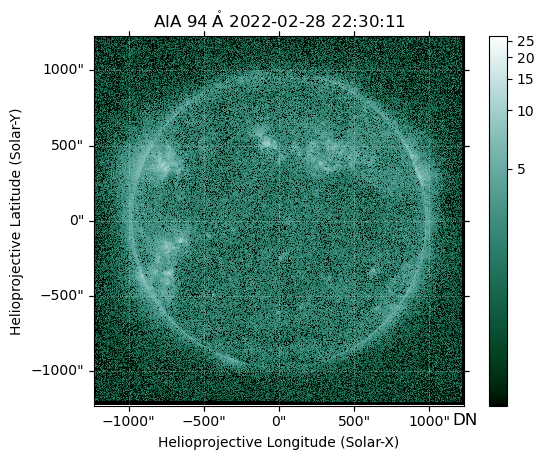

In [ ]:
# errors_94
map_94_errors = Map(errors_94.value, maps['94'].meta)
map_94_errors.peek()

errors_94 / edn_in 的比值统计:
mean: 1.0190624125096692


median: 1.014394162244165
min: 1.0008662430842865
max: 1.0435770416991883


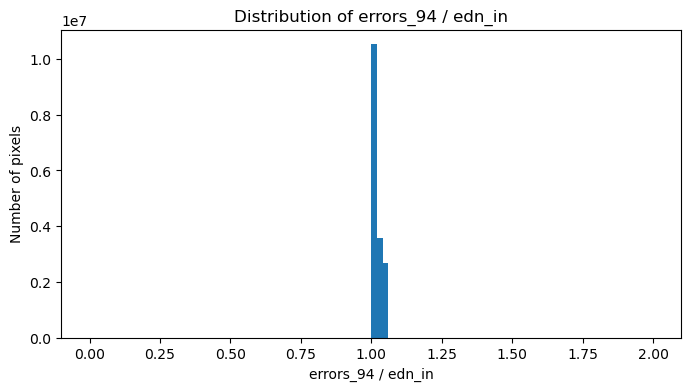

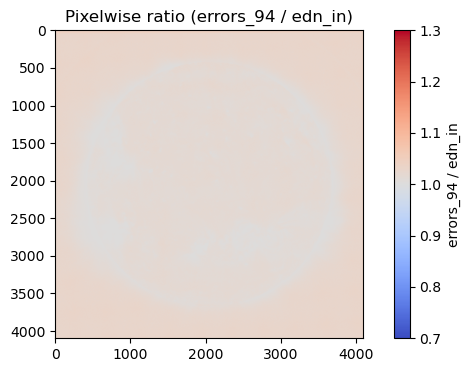

In [58]:
# 比较 errors_94 与 edn_in 的差别，是否相近

import numpy as np
import matplotlib.pyplot as plt

# 注意要将 errors_94 归一到相同的单位（与 edn_in 一致），即每秒
edn_in_dn = edn_in # edn_in 本身就是 DN/px
errors_94_dn = errors_94.value

ratio = errors_94_dn / edn_in_dn

print("errors_94 / edn_in 的比值统计:")
print("mean:", np.nanmean(ratio))
print("median:", np.nanmedian(ratio))
print("min:", np.nanmin(ratio))
print("max:", np.nanmax(ratio))

plt.figure(figsize=(8,4))
plt.hist(ratio.flatten(), bins=100, range=(0,2))
plt.xlabel("errors_94 / edn_in")
plt.ylabel("Number of pixels")
plt.title("Distribution of errors_94 / edn_in")
plt.show()

plt.figure(figsize=(8,4))
plt.imshow(ratio, vmin=0.7, vmax=1.3, cmap='coolwarm')
plt.colorbar(label="errors_94 / edn_in")
plt.title("Pixelwise ratio (errors_94 / edn_in)")
plt.show()

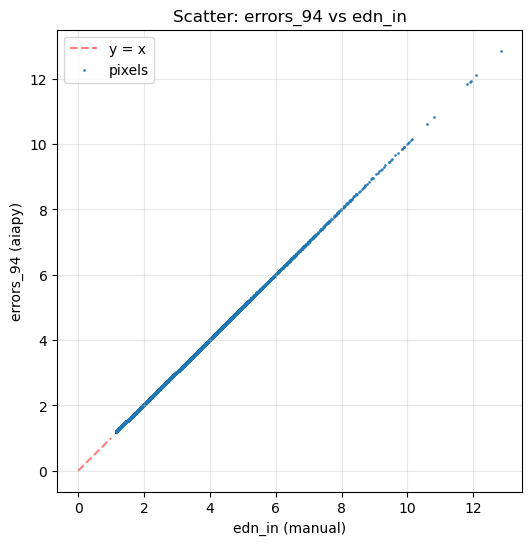

In [57]:

# 再画个 x-y 的散点图，并画 y=x 的线
plt.figure(figsize=(6,6))
# 采样一些点以便散点图不会过多，避免内存问题
sample_size = 50000
edn_flat = edn_in_dn.flatten()
err_flat = errors_94_dn.flatten()
mask = (~np.isnan(edn_flat)) & (~np.isnan(err_flat)) & (edn_flat > 0) & (err_flat > 0)
edn_valid = edn_flat[mask]
err_valid = err_flat[mask]
if len(edn_valid) > sample_size:
    idx = np.random.choice(np.arange(len(edn_valid)), size=sample_size, replace=False)
    edn_valid = edn_valid[idx]
    err_valid = err_valid[idx]

xlim = plt.xlim()
plt.plot(xlim, xlim, 'r--', label='y = x',alpha=0.5)
plt.scatter(edn_valid, err_valid, s=1, alpha=0.8, label='pixels')


plt.xlabel("edn_in (manual)")
plt.ylabel("errors_94 (aiapy)")
plt.title("Scatter: errors_94 vs edn_in")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Therefore, manual 和 aiapy 提供的 uncertainty 接近